In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [3]:
df.shape

(27, 2)

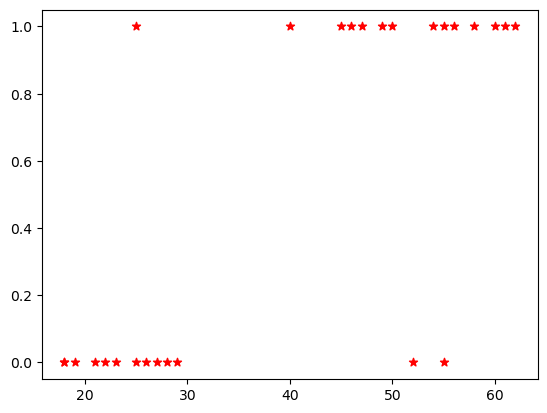

In [4]:
plt.scatter(df.age,df.bought_insurance, color = 'red', marker = '*')

In [5]:
X = df[['age']]
y = df['bought_insurance']

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y , random_state=10,train_size=0.8)

In [8]:
model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
coef = model.coef_
coef

array([[0.112778]])

In [10]:
intercept = model.intercept_
intercept

array([-4.20278276])

In [11]:
y_prediction = model.predict(X_test)
y_prediction

array([1, 1, 0, 0, 0, 0])

In [12]:
df['probs'] = model.predict_proba(df[['age']])[:,1]
df

,age,bought_insurance,probs
0,22,0,0.151657
1,25,0,0.200474
2,47,1,0.749845
3,52,0,0.840463
4,46,1,0.728100
5,56,1,0.892140
6,55,0,0.880798
7,60,1,0.928502
8,62,1,0.942103
9,61,1,0.935636


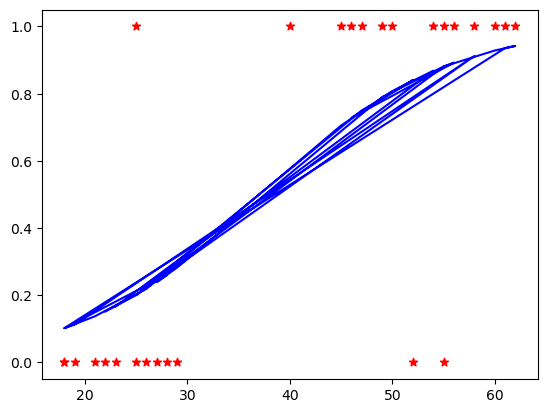

In [14]:
plt.scatter(df['age'],df['bought_insurance'],color = 'red',marker = '*')
plt.plot(df['age'],df['probs'],color = 'blue')

In [21]:
import math

def sigmoid(z):
    return 1/(1 + math.exp(-z))

In [22]:
def predicting_age(age):
    z = coef * age + (intercept)
    y = sigmoid(z)
    return y

In [26]:
predicting_age([57])

C:\Users\Abhishek\AppData\Local\Temp\ipykernel_21912\3970846820.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1/(1 + math.exp(-z))


0.9025217404643333